# P9 - Analyse de la Saisonnalité
## Détecter les patterns répétitifs dans une série temporelle

---

### 🎯 Objectifs de ce notebook

Apprendre à **détecter** et **valider** un pattern saisonnier dans une série temporelle avec des méthodes simples et accessibles.

### 📚 Ce que vous allez apprendre

| Méthode | Difficulté | Ce qu'elle montre |
|---------|------------|-------------------|
| Agrégation par jour du cycle | ⭐ | Pattern visuel simple |
| Graphique d'autocorrélation (ACF) | ⭐⭐ | Pics aux périodes significatives |
| Coefficient d'autocorrélation | ⭐⭐ | Valeur numérique du pattern |
| Décomposition saisonnière | ⭐⭐⭐ | Tendance + Saison + Résidus |
| Comparaison de périodes | ⭐⭐⭐ | Quelle période est la meilleure |

---

## 1. Configuration et chargement des données

In [1]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Bibliothèques statistiques
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import seasonal_decompose

# Configuration
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliothèques chargées avec succès !")

✅ Bibliothèques chargées avec succès !


In [2]:
# Charger les données préparées au Jour 2
DATA_PATH = "../data/processed/"

df = pd.read_csv(DATA_PATH + "transactions_enrichies.csv")
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Données chargées : {len(df):,} transactions")
print(f"   Période : {df['date'].min().date()} → {df['date'].max().date()}")

✅ Données chargées : 687,534 transactions
   Période : 2021-03-01 → 2023-02-28


In [3]:
# Conserver uniquement les transactions B2C
df = df[df['segment_client'] == 'B2C']

# Calculer le CA journalier
ca_journalier = df.groupby(pd.Grouper(key='date', freq='D'))['price'].sum().reset_index()
ca_journalier.columns = ['date', 'ca']
ca_journalier = ca_journalier.sort_values('date').reset_index(drop=True)

print(f"✅ CA journalier calculé : {len(ca_journalier)} jours")
display(ca_journalier.head())

✅ CA journalier calculé : 730 jours


,date,ca
0,2021-03-01,15468.65
1,2021-03-02,14558.47
2,2021-03-03,13899.99
3,2021-03-04,13567.62
4,2021-03-05,16216.09


---

## 2. Visualisation initiale

Avant d'analyser la saisonnalité, visualisons nos données pour avoir une première intuition.

In [4]:
# Visualisation du CA journalier
fig = px.line(
    ca_journalier,
    x='date',
    y='ca',
    title="Évolution du CA journalier - Lapage",
    labels={'date': 'Date', 'ca': 'Chiffre d\'Affaires (€)'}
)

fig.update_traces(line=dict(color='#2196F3', width=1))
fig.update_layout(
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

### 🤔 Questions à se poser

En observant le graphique :
- Y a-t-il des **pics récurrents** à intervalles réguliers ?
- Les **creux** reviennent-ils de manière prévisible ?
- Quelle pourrait être la **période** de ce pattern ? (7 jours ? 14 jours ? autre ?)

---

## 3. Méthode 1 : Agrégation par jour du cycle ⭐

### 📚 Principe

Si on suppose un cycle de **N jours**, on peut :
1. Numéroter chaque jour de 0 à N-1
2. Calculer le CA moyen pour chaque position dans le cycle
3. Visualiser : si certains jours sont systématiquement plus hauts, il y a un pattern

### Exemple avec un cycle de 7 jours (semaine)

In [5]:
# Ajouter le jour de la semaine (0 = Lundi, 6 = Dimanche)
ca_journalier['jour_semaine'] = ca_journalier['date'].dt.dayofweek

# Mapping pour les noms de jours
jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
ca_journalier['jour_nom'] = ca_journalier['jour_semaine'].map(lambda x: jours[x])

# CA moyen par jour de la semaine
ca_par_jour_semaine = ca_journalier.groupby(['jour_semaine', 'jour_nom'])['ca'].mean().reset_index()
ca_par_jour_semaine = ca_par_jour_semaine.sort_values('jour_semaine')

# Visualisation
fig = px.bar(
    ca_par_jour_semaine,
    x='jour_nom',
    y='ca',
    title="CA moyen par jour de la semaine (cycle 7 jours)",
    labels={'jour_nom': 'Jour', 'ca': 'CA moyen (€)'},
    color='ca',
    color_continuous_scale='Blues'
)

fig.update_layout(template='plotly_white', showlegend=False)
fig.show()

print("📊 CA moyen par jour de la semaine :")
display(ca_par_jour_semaine[['jour_nom', 'ca']].round(2))

📊 CA moyen par jour de la semaine :


,jour_nom,ca
0,Lundi,15327.26
1,Mardi,15294.84
2,Mercredi,15207.35
3,Jeudi,15252.47
4,Vendredi,15195.45
5,Samedi,15235.10
6,Dimanche,15340.84


### Exemple avec un cycle de 14 jours (quinzaine)

In [6]:
# Créer un indicateur "jour dans le cycle de 14 jours"
# On calcule le nombre de jours depuis le début, puis on prend le modulo 14
date_debut = ca_journalier['date'].min()
ca_journalier['jour_cycle_14'] = (ca_journalier['date'] - date_debut).dt.days % 14

# CA moyen par jour du cycle
ca_par_jour_cycle_14 = ca_journalier.groupby('jour_cycle_14')['ca'].mean().reset_index()

# Visualisation
fig = px.bar(
    ca_par_jour_cycle_14,
    x='jour_cycle_14',
    y='ca',
    title="CA moyen par jour du cycle de 14 jours",
    labels={'jour_cycle_14': 'Jour du cycle (0-13)', 'ca': 'CA moyen (€)'},
    color='ca',
    color_continuous_scale='Oranges'
)

fig.update_layout(template='plotly_white', showlegend=False)
fig.update_xaxes(tickmode='linear', dtick=1)
fig.show()

### 📝 Comment interpréter ?

| Observation | Interprétation |
|-------------|----------------|
| Barres de hauteurs très différentes | Pattern marqué |
| Barres de hauteurs similaires | Pas de pattern pour cette période |
| Pics régulièrement espacés | Sous-cycle possible (ex: pics tous les 7 jours dans un cycle de 14) |

---

## 4. Méthode 2 : Graphique d'autocorrélation (ACF) ⭐⭐

### 📚 Qu'est-ce que l'autocorrélation ?

L'**autocorrélation** mesure à quel point une série est corrélée avec **elle-même décalée dans le temps**.

```
Données originales :    10  20  15  10  20  15  10  20  15
Décalées de 3 jours :            10  20  15  10  20  15  10  20  15
                                  ↑   ↑   ↑   ↑   ↑   ↑
                              Corrélation forte ! (même pattern)
```

- **Lag** = décalage en nombre de jours
- Si l'autocorrélation au **lag 7** est forte → pattern hebdomadaire
- Si l'autocorrélation au **lag 14** est forte → pattern de 14 jours

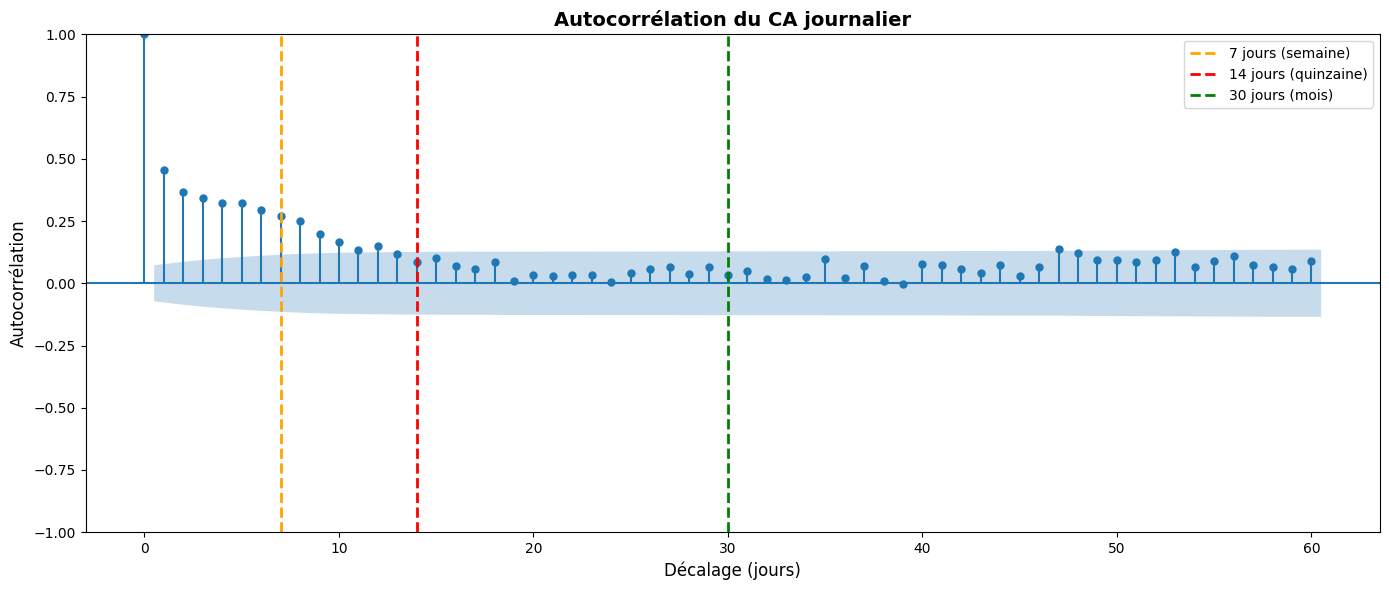

In [7]:
# Graphique d'autocorrélation avec matplotlib
fig, ax = plt.subplots(figsize=(14, 6))

# Tracer l'ACF jusqu'à 60 jours
plot_acf(ca_journalier['ca'].dropna(), lags=60, ax=ax, alpha=0.05)

# Ajouter des lignes verticales pour les périodes d'intérêt
ax.axvline(x=7, color='orange', linestyle='--', linewidth=2, label='7 jours (semaine)')
ax.axvline(x=14, color='red', linestyle='--', linewidth=2, label='14 jours (quinzaine)')
ax.axvline(x=30, color='green', linestyle='--', linewidth=2, label='30 jours (mois)')

ax.set_title("Autocorrélation du CA journalier", fontsize=14, fontweight='bold')
ax.set_xlabel("Décalage (jours)", fontsize=12)
ax.set_ylabel("Autocorrélation", fontsize=12)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 📖 Comment lire ce graphique ?

| Élément | Signification |
|---------|---------------|
| **Barres bleues** | Autocorrélation à chaque lag |
| **Zone bleutée** | Intervalle de confiance à 95% |
| **Barre qui dépasse la zone** | Autocorrélation **significative** |
| **Pic au lag 7, 14, 21...** | Pattern hebdomadaire |
| **Pic au lag 14, 28, 42...** | Pattern bi-hebdomadaire |

---

## 5. Méthode 3 : Coefficients d'autocorrélation (valeurs numériques) ⭐⭐

### 📚 Principe

Plutôt que de lire un graphique, on peut extraire les **valeurs exactes** de l'autocorrélation pour les périodes qui nous intéressent.

In [8]:
# Calculer l'autocorrélation pour différents lags
autocorr = acf(ca_journalier['ca'].dropna(), nlags=35)

# Périodes à tester
periodes_test = [1, 7, 14, 21, 28, 30]

print("=" * 50)
print("📊 COEFFICIENTS D'AUTOCORRÉLATION")
print("=" * 50)
print()

for lag in periodes_test:
    valeur = autocorr[lag]
    
    # Indicateur visuel de force
    if abs(valeur) > 0.5:
        force = "🟢 FORT"
    elif abs(valeur) > 0.3:
        force = "🟡 Modéré"
    elif abs(valeur) > 0.2:
        force = "🟠 Faible"
    else:
        force = "⚪ Très faible"
    
    print(f"   Lag {lag:2} jours : {valeur:+.3f}  {force}")

print()
print("=" * 50)

📊 COEFFICIENTS D'AUTOCORRÉLATION

   Lag  1 jours : +0.455  🟡 Modéré
   Lag  7 jours : +0.269  🟠 Faible
   Lag 14 jours : +0.085  ⚪ Très faible
   Lag 21 jours : +0.031  ⚪ Très faible
   Lag 28 jours : +0.038  ⚪ Très faible
   Lag 30 jours : +0.033  ⚪ Très faible



In [9]:
# Trouver automatiquement les pics d'autocorrélation
print("🔍 RECHERCHE AUTOMATIQUE DES PICS")
print("-" * 40)

# Exclure le lag 0 (toujours = 1) et lag 1 (souvent fort par inertie)
autocorr_sans_lag01 = autocorr[2:]
lags = list(range(2, len(autocorr)))

# Trouver les 5 plus forts lags
top_indices = np.argsort(autocorr_sans_lag01)[::-1][:5]

print("\nTop 5 des lags avec la plus forte autocorrélation :\n")
for i, idx in enumerate(top_indices, 1):
    lag = lags[idx]
    val = autocorr_sans_lag01[idx]
    print(f"   {i}. Lag {lag:2} jours : {val:+.3f}")

🔍 RECHERCHE AUTOMATIQUE DES PICS
----------------------------------------

Top 5 des lags avec la plus forte autocorrélation :

   1. Lag  2 jours : +0.368
   2. Lag  3 jours : +0.343
   3. Lag  5 jours : +0.322
   4. Lag  4 jours : +0.321
   5. Lag  6 jours : +0.294


### 📝 Grille d'interprétation

| Valeur d'autocorrélation | Interprétation |
|--------------------------|----------------|
| > 0.7 | Très forte → Pattern très marqué ✅ |
| 0.5 - 0.7 | Forte → Pattern clair |
| 0.3 - 0.5 | Modérée → Pattern présent |
| 0.2 - 0.3 | Faible → Pattern léger |
| < 0.2 | Très faible → Pas de pattern significatif |

---

## 6. Méthode 4 : Décomposition saisonnière ⭐⭐⭐

### 📚 Principe

La **décomposition saisonnière** sépare une série temporelle en 3 composantes :

```
Données observées = Tendance + Saisonnalité + Résidus
```

| Composante | Ce qu'elle représente |
|------------|----------------------|
| **Tendance** | Direction générale (hausse, baisse, stable) |
| **Saisonnalité** | Pattern répétitif de période fixe |
| **Résidus** | Ce qui reste (bruit, anomalies) |

In [10]:
# Préparer les données pour la décomposition
# On doit avoir une série avec un index temporel
serie_ca = ca_journalier.set_index('date')['ca']

# Vérifier qu'il n'y a pas de trous dans les dates
print(f"Nombre de jours dans la série : {len(serie_ca)}")
print(f"Valeurs manquantes : {serie_ca.isna().sum()}")

Nombre de jours dans la série : 730
Valeurs manquantes : 0


In [11]:
# Décomposition avec une période de 14 jours
PERIODE = 14

decomposition = seasonal_decompose(
    serie_ca,
    model='additive',   # Modèle additif : Observé = Tendance + Saison + Résidus
    period=PERIODE
)

print(f"✅ Décomposition effectuée avec période = {PERIODE} jours")

✅ Décomposition effectuée avec période = 14 jours


C:\Users\RémiJulien\AppData\Local\Temp\ipykernel_34092\605236752.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RémiJulien\AppData\Local\Temp\ipykernel_34092\605236752.py:26: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RémiJulien\AppData\Local\Temp\ipykernel_34092\605236752.py:26: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RémiJulien\AppData\Local\Temp\ipykernel_34092\605236752.py:26: UserWarning: Glyph 127922 (\N{GAME DIE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\RémiJulien\OneDrive\Documents\DcidConsulting\2.Prestation\3.Formation\3.Production\2025_GRETA DEV IA_P5\OCR_Projet_9\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.ca

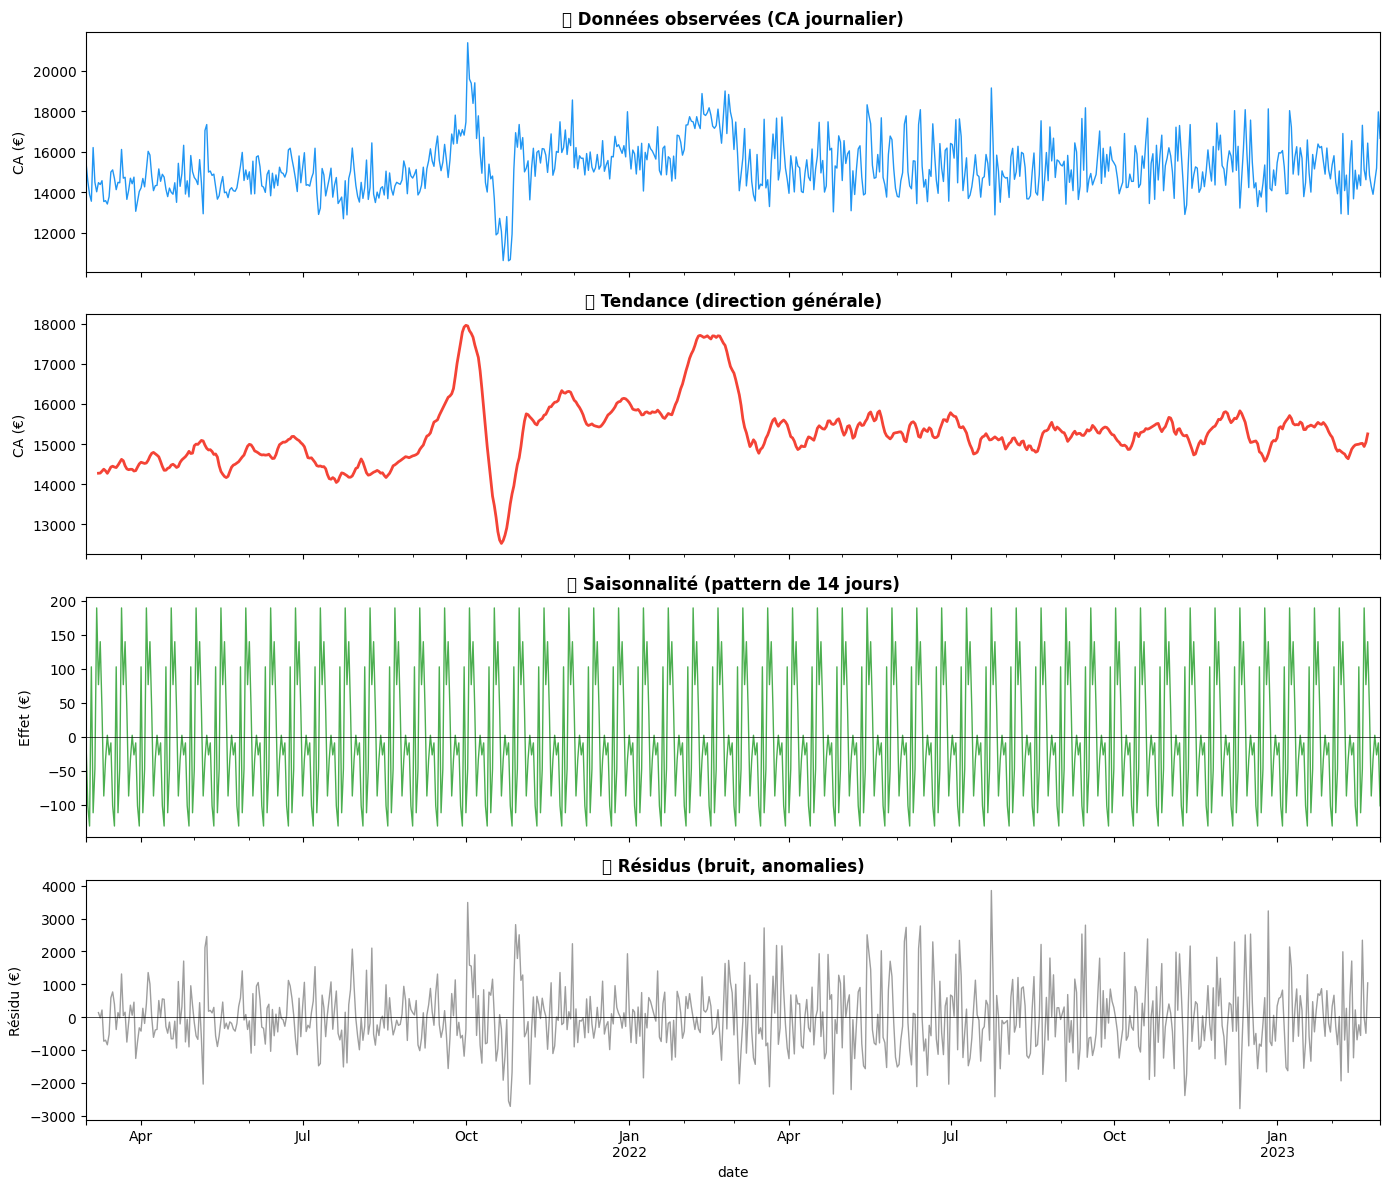

In [12]:
# Visualisation des 4 composantes
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# 1. Données observées
decomposition.observed.plot(ax=axes[0], color='#2196F3', linewidth=1)
axes[0].set_title('📊 Données observées (CA journalier)', fontweight='bold')
axes[0].set_ylabel('CA (€)')

# 2. Tendance
decomposition.trend.plot(ax=axes[1], color='#F44336', linewidth=2)
axes[1].set_title('📈 Tendance (direction générale)', fontweight='bold')
axes[1].set_ylabel('CA (€)')

# 3. Saisonnalité
decomposition.seasonal.plot(ax=axes[2], color='#4CAF50', linewidth=1)
axes[2].set_title(f'🔄 Saisonnalité (pattern de {PERIODE} jours)', fontweight='bold')
axes[2].set_ylabel('Effet (€)')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 4. Résidus
decomposition.resid.plot(ax=axes[3], color='#9E9E9E', linewidth=1)
axes[3].set_title('🎲 Résidus (bruit, anomalies)', fontweight='bold')
axes[3].set_ylabel('Résidu (€)')
axes[3].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

In [13]:
# Zoomer sur le pattern saisonnier (1 ou 2 cycles)
# On prend les premières valeurs de la composante saisonnière
pattern_saisonnier = decomposition.seasonal[:PERIODE*2]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(pattern_saisonnier))),
    y=pattern_saisonnier.values,
    mode='lines+markers',
    name='Pattern saisonnier',
    line=dict(color='#4CAF50', width=2),
    marker=dict(size=8)
))

# Ajouter des lignes verticales pour marquer les cycles
for i in range(0, PERIODE*2 + 1, PERIODE):
    fig.add_vline(x=i, line_dash="dash", line_color="red", opacity=0.5)

fig.update_layout(
    title=f"Zoom sur le pattern saisonnier ({PERIODE} jours)",
    xaxis_title="Jour dans le cycle",
    yaxis_title="Effet sur le CA (€)",
    template='plotly_white'
)

fig.show()

### 📝 Comment interpréter la décomposition ?

| Composante | Ce qu'il faut regarder |
|------------|------------------------|
| **Tendance** | Monte ? Descend ? Stable ? |
| **Saisonnalité** | Amplitude du pattern (grand écart = fort impact) |
| **Résidus** | Sont-ils "aléatoires" ou contiennent-ils des patterns non captés ? |

---

## 7. Méthode 5 : Comparaison de plusieurs périodes ⭐⭐⭐

### 📚 Principe

On ne sait pas toujours quelle est la "bonne" période. Cette méthode teste plusieurs périodes et compare leur **pouvoir explicatif**.

In [14]:
# Tester plusieurs périodes candidates
periodes_test = [7, 14, 21, 28, 30]
resultats = []

for p in periodes_test:
    try:
        # Décomposition avec cette période
        decomp = seasonal_decompose(serie_ca, model='additive', period=p)
        
        # Calculer la variance de chaque composante
        var_observed = np.nanvar(decomp.observed)
        var_seasonal = np.nanvar(decomp.seasonal)
        var_resid = np.nanvar(decomp.resid)
        
        # Ratio : quelle part de la variance est expliquée par la saisonnalité ?
        ratio_seasonal = (var_seasonal / var_observed) * 100
        ratio_resid = (var_resid / var_observed) * 100
        
        resultats.append({
            'periode': p,
            'var_saisonnalite': var_seasonal,
            'var_residus': var_resid,
            'pct_saisonnalite': ratio_seasonal,
            'pct_residus': ratio_resid
        })
    except Exception as e:
        print(f"⚠️ Erreur avec période {p}: {e}")

resultats_df = pd.DataFrame(resultats)

In [15]:
# Afficher les résultats
print("=" * 70)
print("📊 COMPARAISON DES PÉRIODES DE SAISONNALITÉ")
print("=" * 70)
print()

# Formater pour l'affichage
resultats_affichage = resultats_df.copy()
resultats_affichage['pct_saisonnalite'] = resultats_affichage['pct_saisonnalite'].round(1).astype(str) + ' %'
resultats_affichage['pct_residus'] = resultats_affichage['pct_residus'].round(1).astype(str) + ' %'

display(resultats_affichage[['periode', 'pct_saisonnalite', 'pct_residus']])

# Identifier la meilleure période
best_idx = resultats_df['pct_saisonnalite'].idxmax()
best_periode = resultats_df.loc[best_idx, 'periode']
best_pct = resultats_df.loc[best_idx, 'pct_saisonnalite']

print()
print(f"🎯 Meilleure période : {best_periode} jours")
print(f"   → Explique {best_pct:.1f}% de la variance par la saisonnalité")

📊 COMPARAISON DES PÉRIODES DE SAISONNALITÉ



,periode,pct_saisonnalite,pct_residus
0,7,0.1 %,50.7 %
1,14,0.5 %,56.8 %
2,21,1.6 %,61.5 %
3,28,2.1 %,66.4 %
4,30,3.5 %,66.7 %



🎯 Meilleure période : 30 jours
   → Explique 3.5% de la variance par la saisonnalité


In [16]:
# Visualiser la comparaison
fig = px.bar(
    resultats_df,
    x='periode',
    y='pct_saisonnalite',
    title="Part de variance expliquée par la saisonnalité selon la période",
    labels={'periode': 'Période (jours)', 'pct_saisonnalite': 'Variance expliquée (%)'},
    color='pct_saisonnalite',
    color_continuous_scale='Greens',
    text='pct_saisonnalite'
)

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(template='plotly_white', showlegend=False)
fig.update_xaxes(tickmode='linear', dtick=7)

fig.show()

### 📝 Comment interpréter ?

| Critère | Bonne période | Mauvaise période |
|---------|---------------|------------------|
| % Saisonnalité | Élevé (>10%) | Faible (<5%) |
| % Résidus | Faible | Élevé |
| Sens métier | Cohérent (semaine, mois...) | Arbitraire |

---

## 8. Fonction récapitulative 🎁

Voici une fonction prête à l'emploi qui combine les méthodes précédentes.

**Version 1**

In [17]:
def analyser_saisonnalite(df, col_date, col_valeur, periodes_test=[7, 14, 21, 28, 30]):
    """
    Analyse la saisonnalité d'une série temporelle.
    
    Paramètres:
    -----------
    df : DataFrame contenant les données
    col_date : nom de la colonne date
    col_valeur : nom de la colonne à analyser
    periodes_test : liste des périodes à tester
    
    Retourne:
    ---------
    dict avec la meilleure période et les résultats détaillés
    """
    
    print("=" * 60)
    print("📊 ANALYSE DE SAISONNALITÉ")
    print("=" * 60)
    
    # Préparer les données
    data = df[col_valeur].dropna()
    
    # 1. Autocorrélation
    print("\n1️⃣  AUTOCORRÉLATION PAR PÉRIODE")
    print("-" * 40)
    
    autocorr = acf(data, nlags=max(periodes_test) + 5)
    
    resultats_acf = {}
    for p in periodes_test:
        val = autocorr[p]
        resultats_acf[p] = val
        
        # Indicateur visuel
        if val > 0.5:
            symbole = "🟢"
        elif val > 0.3:
            symbole = "🟡"
        elif val > 0.2:
            symbole = "🟠"
        else:
            symbole = "⚪"
        
        print(f"   {symbole} Période {p:2} jours : {val:+.3f}")
    
    # 2. Meilleure période par autocorrélation
    best_period_acf = max(resultats_acf, key=resultats_acf.get)
    best_corr = resultats_acf[best_period_acf]
    
    print("\n2️⃣  SYNTHÈSE")
    print("-" * 40)
    print(f"   🎯 Période la plus probable : {best_period_acf} jours")
    print(f"   📈 Force du pattern (autocorrélation) : {best_corr:.3f}", end=" ")
    
    if best_corr > 0.5:
        print("→ FORT ✅")
    elif best_corr > 0.3:
        print("→ Modéré 🟡")
    elif best_corr > 0.2:
        print("→ Faible 🟠")
    else:
        print("→ Très faible ⚪")
    
    print("\n" + "=" * 60)
    
    return {
        'meilleure_periode': best_period_acf,
        'autocorrelation': best_corr,
        'resultats_detailles': resultats_acf
    }

In [18]:
# Utilisation de la fonction
resultats = analyser_saisonnalite(
    ca_journalier, 
    col_date='date', 
    col_valeur='ca',
    periodes_test=[7, 14, 21, 28, 30]
)

print(f"\n📌 Résultat : la période de {resultats['meilleure_periode']} jours est la plus pertinente.")

📊 ANALYSE DE SAISONNALITÉ

1️⃣  AUTOCORRÉLATION PAR PÉRIODE
----------------------------------------
   🟠 Période  7 jours : +0.269
   ⚪ Période 14 jours : +0.085
   ⚪ Période 21 jours : +0.031
   ⚪ Période 28 jours : +0.038
   ⚪ Période 30 jours : +0.033

2️⃣  SYNTHÈSE
----------------------------------------
   🎯 Période la plus probable : 7 jours
   📈 Force du pattern (autocorrélation) : 0.269 → Faible 🟠


📌 Résultat : la période de 7 jours est la plus pertinente.


**Version 2**

In [19]:
def analyser_saisonnalite(df, col_date, col_valeur, periodes_test=[7, 10, 14, 20, 21, 28, 30]):
    """
    Analyse la saisonnalité d'une série temporelle.
    """
    from statsmodels.tsa.stattools import acf
    
    print("=" * 60)
    print("📊 ANALYSE DE SAISONNALITÉ")
    print("=" * 60)
    
    data = df[col_valeur].dropna()
    autocorr = acf(data, nlags=max(periodes_test) + 5)
    
    print("\n1️⃣  AUTOCORRÉLATION PAR PÉRIODE")
    print("-" * 40)
    
    resultats_acf = {}
    for p in periodes_test:
        val = autocorr[p]
        resultats_acf[p] = val
        
        if val > 0.5:
            symbole = "🟢"
        elif val > 0.3:
            symbole = "🟡"
        elif val > 0.2:
            symbole = "🟠"
        else:
            symbole = "⚪"
        
        print(f"   {symbole} Période {p:2} jours : {val:+.3f}")
    
    # Meilleure période
    best_period = max(resultats_acf, key=resultats_acf.get)
    best_corr = resultats_acf[best_period]
    
    print("\n2️⃣  CONCLUSION")
    print("-" * 40)
    
    # Conclusion adaptée à la force du signal
    if best_corr > 0.5:
        print(f"   🎯 Pattern FORT détecté : {best_period} jours")
        print(f"   📈 Autocorrélation : {best_corr:.3f} → Saisonnalité exploitable ✅")
        conclusion = "saisonnalite_forte"
    elif best_corr > 0.3:
        print(f"   🎯 Pattern MODÉRÉ détecté : {best_period} jours")
        print(f"   📈 Autocorrélation : {best_corr:.3f} → Saisonnalité présente 🟡")
        conclusion = "saisonnalite_moderee"
    elif best_corr > 0.2:
        print(f"   🎯 Pattern FAIBLE détecté : {best_period} jours")
        print(f"   📈 Autocorrélation : {best_corr:.3f} → Légère tendance, non significative 🟠")
        print(f"\n   💡 Interprétation : il existe une très légère variation {best_period} jours,")
        print(f"      mais elle n'est pas assez forte pour être exploitée en prévision.")
        conclusion = "saisonnalite_faible"
    else:
        print(f"   ❌ PAS DE SAISONNALITÉ DÉTECTÉE")
        print(f"   📈 Meilleure autocorrélation : {best_corr:.3f} (période {best_period}j) → Non significatif ⚪")
        print(f"\n   💡 Interprétation : le CA journalier ne suit pas de cycle régulier.")
        print(f"      C'est une information utile : pas besoin d'adapter les ressources")
        print(f"      selon un pattern temporel.")
        conclusion = "pas_de_saisonnalite"
    
    print("\n" + "=" * 60)
    
    return {
        'meilleure_periode': best_period,
        'autocorrelation': best_corr,
        'conclusion': conclusion,
        'resultats_detailles': resultats_acf
    }

In [20]:
# CA journalier par catégorie
for cat in df['categ'].unique():
    print(f"\n📚 Catégorie : {cat}")
    df_cat = df[df['categ'] == cat]
    ca_cat = df_cat.groupby(pd.Grouper(key='date', freq='D'))['price'].sum().reset_index()
    ca_cat.columns = ['date', 'ca']
    analyser_saisonnalite(ca_cat, 'date', 'ca', periodes_test=[3, 5, 7, 10, 14, 20, 21, 28, 30])


📚 Catégorie : 0
📊 ANALYSE DE SAISONNALITÉ

1️⃣  AUTOCORRÉLATION PAR PÉRIODE
----------------------------------------
   🟡 Période  3 jours : +0.398
   🟡 Période  5 jours : +0.372
   🟡 Période  7 jours : +0.362
   🟡 Période 10 jours : +0.314
   🟠 Période 14 jours : +0.257
   ⚪ Période 20 jours : +0.114
   ⚪ Période 21 jours : +0.090
   ⚪ Période 28 jours : -0.008
   ⚪ Période 30 jours : -0.031

2️⃣  CONCLUSION
----------------------------------------
   🎯 Pattern MODÉRÉ détecté : 3 jours
   📈 Autocorrélation : 0.398 → Saisonnalité présente 🟡


📚 Catégorie : 1
📊 ANALYSE DE SAISONNALITÉ

1️⃣  AUTOCORRÉLATION PAR PÉRIODE
----------------------------------------
   🟡 Période  3 jours : +0.454
   🟡 Période  5 jours : +0.405
   🟡 Période  7 jours : +0.345
   🟠 Période 10 jours : +0.269
   🟠 Période 14 jours : +0.216
   🟠 Période 20 jours : +0.221
   ⚪ Période 21 jours : +0.183
   ⚪ Période 28 jours : +0.195
   🟠 Période 30 jours : +0.211

2️⃣  CONCLUSION
-------------------------------------

---

## 9. Récapitulatif 📝

### Ce que vous avez appris

| Méthode | Fonction/Code clé | Quand l'utiliser |
|---------|-------------------|------------------|
| Agrégation par cycle | `df['jour_cycle'] = jours % N` | En premier, pour explorer |
| Graphique ACF | `plot_acf(data, lags=60)` | Pour visualiser les pics |
| Coefficient ACF | `acf(data, nlags=30)` | Pour quantifier la force |
| Décomposition | `seasonal_decompose(data, period=N)` | Pour séparer les composantes |
| Comparaison périodes | Boucle + variance | Pour valider le choix |

### Grille d'interprétation de l'autocorrélation

| Valeur | Force | Interprétation |
|--------|-------|----------------|
| > 0.7 | 🟢 Très forte | Pattern très marqué, prédictible |
| 0.5 - 0.7 | 🟢 Forte | Pattern clair |
| 0.3 - 0.5 | 🟡 Modérée | Pattern présent |
| 0.2 - 0.3 | 🟠 Faible | Pattern léger |
| < 0.2 | ⚪ Très faible | Pas de pattern significatif |

### Bonnes pratiques

1. **Commencer simple** : agrégation par jour du cycle + graphique
2. **Valider numériquement** : autocorrélation
3. **Comprendre en profondeur** : décomposition saisonnière
4. **Toujours vérifier** : la période a-t-elle un sens métier ?

### Prochaines étapes

- Intégrer ces analyses dans votre présentation CODIR
- Utiliser la période identifiée pour les prévisions (Phase 5)
- Explorer si d'autres variables ont des patterns similaires